# Examen No. 4 – Aprendizaje No Supervisado
## Comparación de Algoritmos de Clustering

**Universidad Pontificia Bolivariana**  
Curso: Inteligencia Artificial – Periodo 202610  

DAVID VALLEJO

**Docente:** Juan Darío Rodas  
**Dataset:** Palmer Penguins (UCI Repository)  
**Fecha de entrega:** Viernes 17 de abril de 2026

---
## 1. Importación de librerías

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

!pip install ucimlrepo
from ucimlrepo import fetch_ucirepo

print('Librerías cargadas correctamente.')

Librerías cargadas correctamente.


---
## 2. Carga del dataset

In [7]:
# Carga el dataset de Palmer Penguins usando seaborn, que es más robusto
import seaborn as sns

temp_df = sns.load_dataset('penguins')

# Renombrar columnas para que coincidan con el formato esperado en el resto del notebook
rename_map = {
    'species': 'Species',
    'island': 'Island',
    'bill_length_mm': 'Culmen Length (mm)', # Corregido de 'culmen_length_mm'
    'bill_depth_mm': 'Culmen Depth (mm)',   # Corregido de 'culmen_depth_mm'
    'flipper_length_mm': 'Flipper Length (mm)',
    'body_mass_g': 'Body Mass (g)',
    'sex': 'Sex'
}
temp_df = temp_df.rename(columns=rename_map)

# Separar las características (X_raw) y el objetivo (y_raw)
feature_cols = [
    'Culmen Length (mm)', 'Culmen Depth (mm)', 'Flipper Length (mm)',
    'Body Mass (g)', 'Island', 'Sex'
]
target_col = 'Species'

X_raw = temp_df[feature_cols]
y_raw = temp_df[target_col]

# Unimos todo en un único dataframe para facilitar el EDA
df = pd.concat([X_raw, y_raw], axis=1)

print(f'Dimensiones del dataset: {df.shape}')
print(f'\nColumnas: {list(df.columns)}')
df.head(10)

Dimensiones del dataset: (344, 7)

Columnas: ['Culmen Length (mm)', 'Culmen Depth (mm)', 'Flipper Length (mm)', 'Body Mass (g)', 'Island', 'Sex', 'Species']


,Culmen Length (mm),Culmen Depth (mm),Flipper Length (mm),Body Mass (g),Island,Sex,Species
0,39.1,18.7,181.0,3750.0,Torgersen,Male,Adelie
1,39.5,17.4,186.0,3800.0,Torgersen,Female,Adelie
2,40.3,18.0,195.0,3250.0,Torgersen,Female,Adelie
3,NaN,NaN,NaN,NaN,Torgersen,NaN,Adelie
4,36.7,19.3,193.0,3450.0,Torgersen,Female,Adelie
5,39.3,20.6,190.0,3650.0,Torgersen,Male,Adelie
6,38.9,17.8,181.0,3625.0,Torgersen,Female,Adelie
7,39.2,19.6,195.0,4675.0,Torgersen,Male,Adelie
8,34.1,18.1,193.0,3475.0,Torgersen,NaN,Adelie
9,42.0,20.2,190.0,4250.0,Torgersen,NaN,Adelie


---
## 3. Exploración inicial (EDA)

In [8]:
print('=== Información general del dataset ===')
df.info()

=== Información general del dataset ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Culmen Length (mm)   342 non-null    float64
 1   Culmen Depth (mm)    342 non-null    float64
 2   Flipper Length (mm)  342 non-null    float64
 3   Body Mass (g)        342 non-null    float64
 4   Island               344 non-null    object 
 5   Sex                  333 non-null    object 
 6   Species              344 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB


In [9]:
print('=== Estadísticas descriptivas ===')
df.describe(include='all')

=== Estadísticas descriptivas ===


,Culmen Length (mm),Culmen Depth (mm),Flipper Length (mm),Body Mass (g),Island,Sex,Species
count,342.000000,342.000000,342.000000,342.000000,344,333,344
unique,NaN,NaN,NaN,NaN,3,2,3
top,NaN,NaN,NaN,NaN,Biscoe,Male,Adelie
freq,NaN,NaN,NaN,NaN,168,168,152
mean,43.921930,17.151170,200.915205,4201.754386,NaN,NaN,NaN
std,5.459584,1.974793,14.061714,801.954536,NaN,NaN,NaN
min,32.100000,13.100000,172.000000,2700.000000,NaN,NaN,NaN
25%,39.225000,15.600000,190.000000,3550.000000,NaN,NaN,NaN
50%,44.450000,17.300000,197.000000,4050.000000,NaN,NaN,NaN
75%,48.500000,18.700000,213.000000,4750.000000,NaN,NaN,NaN


In [10]:
print('=== Valores nulos por columna ===')
print(df.isnull().sum())
print(f'\nTotal de filas con al menos un nulo: {df.isnull().any(axis=1).sum()}')

=== Valores nulos por columna ===
Culmen Length (mm)      2
Culmen Depth (mm)       2
Flipper Length (mm)     2
Body Mass (g)           2
Island                  0
Sex                    11
Species                 0
dtype: int64

Total de filas con al menos un nulo: 11


In [11]:
print('=== Distribución de la variable objetivo (especie) ===')
print(df['Species'].value_counts())

=== Distribución de la variable objetivo (especie) ===
Species
Adelie       152
Gentoo       124
Chinstrap     68
Name: count, dtype: int64


In [12]:
# Distribución por isla
print('=== Distribución por isla ===')
print(df['Island'].value_counts())

print('\n=== Distribución por sexo ===')
print(df['Sex'].value_counts())

=== Distribución por isla ===
Island
Biscoe       168
Dream        124
Torgersen     52
Name: count, dtype: int64

=== Distribución por sexo ===
Sex
Male      168
Female    165
Name: count, dtype: int64


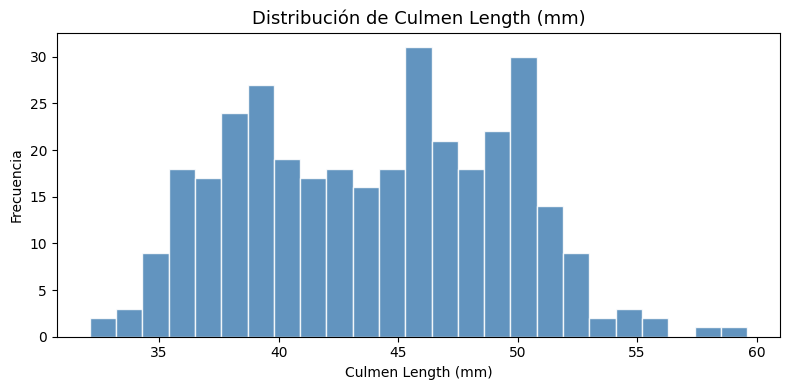

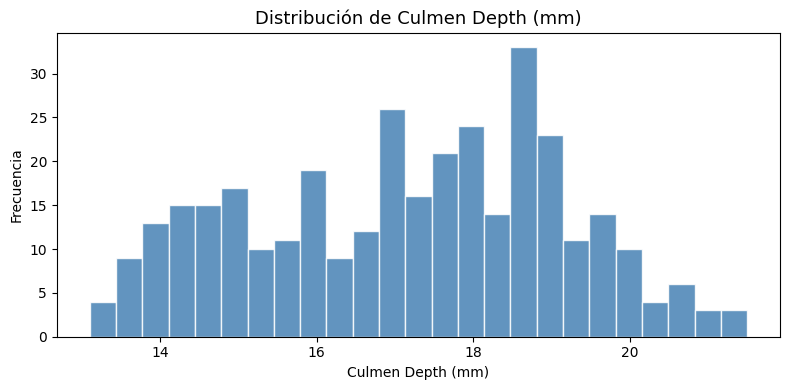

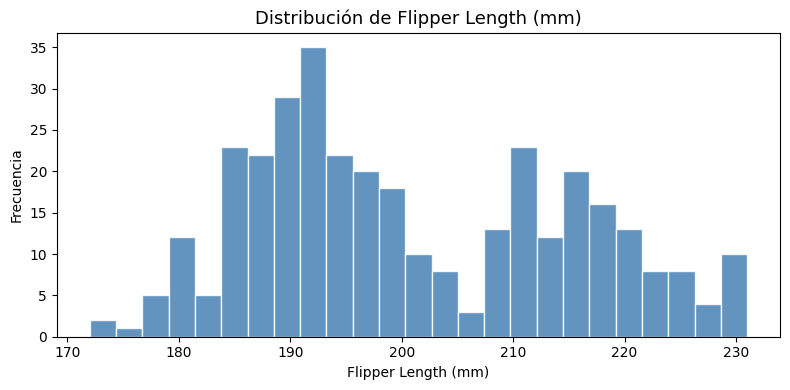

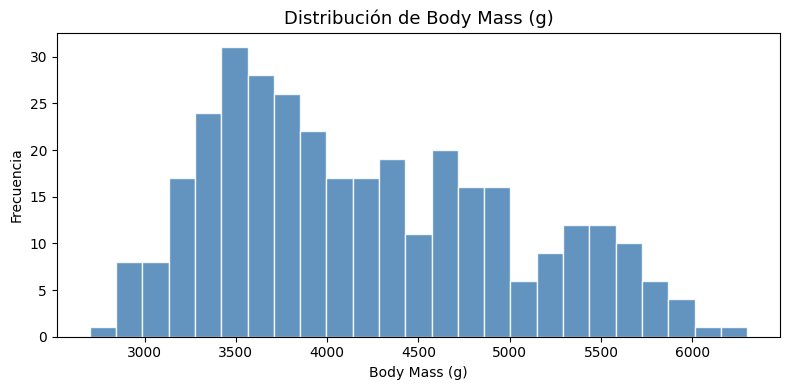

In [13]:
# Histogramas de las variables numéricas
num_cols = ['Culmen Length (mm)', 'Culmen Depth (mm)', 'Flipper Length (mm)', 'Body Mass (g)']

for col in num_cols:
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.hist(df[col].dropna(), bins=25, color='steelblue', edgecolor='white', alpha=0.85)
    ax.set_title(f'Distribución de {col}', fontsize=13)
    ax.set_xlabel(col)
    ax.set_ylabel('Frecuencia')
    plt.tight_layout()
    plt.show()

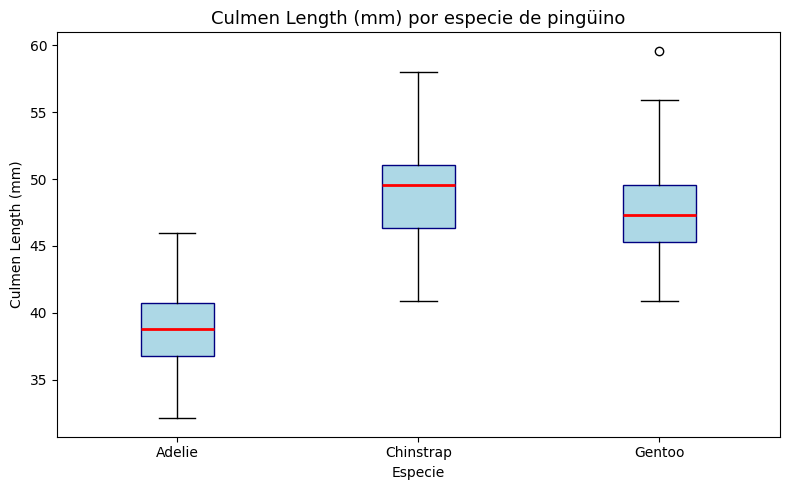

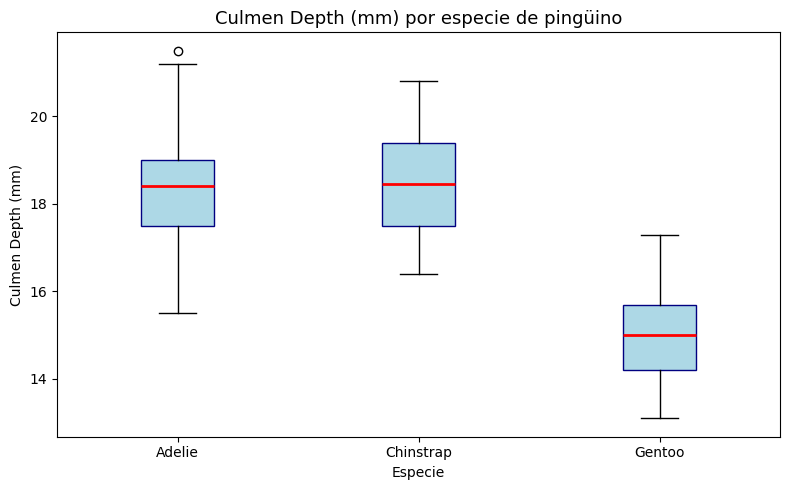

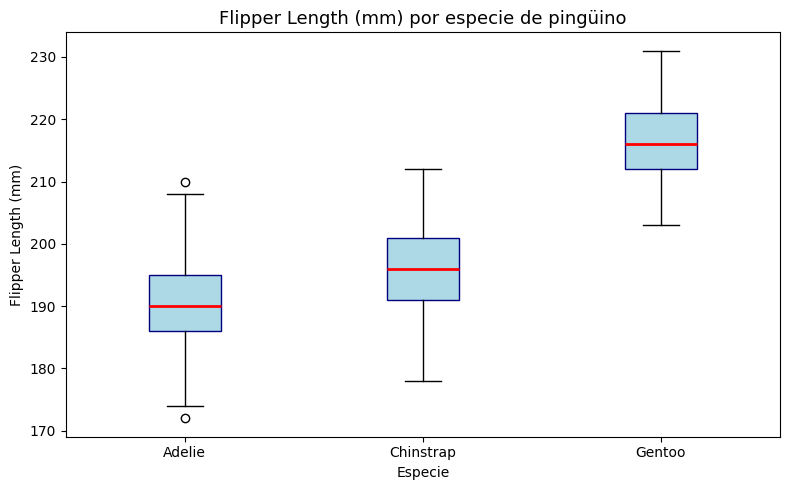

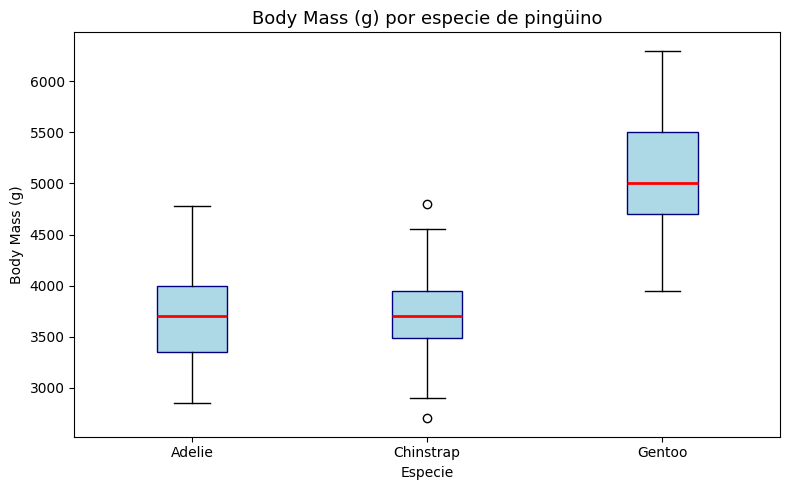

In [14]:
# Boxplots por especie para ver separabilidad natural
for col in num_cols:
    fig, ax = plt.subplots(figsize=(8, 5))
    species_list = df['Species'].dropna().unique()
    data_by_species = [df[df['Species'] == sp][col].dropna().values for sp in species_list]
    bp = ax.boxplot(data_by_species, labels=species_list, patch_artist=True,
                    boxprops=dict(facecolor='lightblue', color='navy'),
                    medianprops=dict(color='red', linewidth=2))
    ax.set_title(f'{col} por especie de pingüino', fontsize=13)
    ax.set_xlabel('Especie')
    ax.set_ylabel(col)
    plt.tight_layout()
    plt.show()

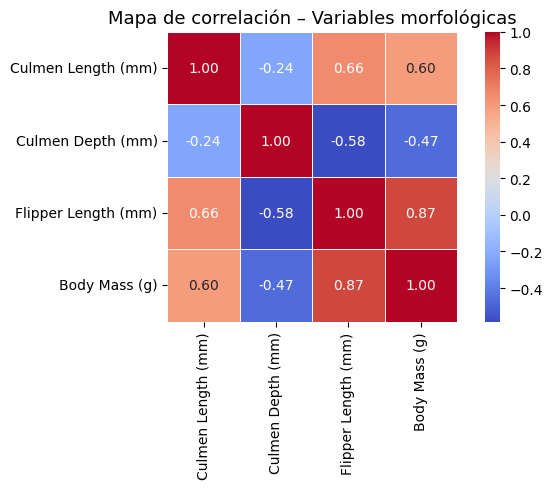

In [15]:
# Mapa de calor de correlaciones entre variables numéricas
fig, ax = plt.subplots(figsize=(7, 5))
corr = df[num_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', ax=ax,
            linewidths=0.5, square=True)
ax.set_title('Mapa de correlación – Variables morfológicas', fontsize=13)
plt.tight_layout()
plt.show()

---
## 4. Preprocesamiento de datos

In [16]:
# Separamos la etiqueta real (ground truth) antes de limpiar
# La usaremos sólo para comparación visual, nunca para entrenar

df_clean = df.copy()

# Eliminamos filas con nulos en columnas relevantes
cols_relevantes = num_cols + ['Island', 'Sex', 'Species']
df_clean = df_clean.dropna(subset=cols_relevantes)
df_clean = df_clean.reset_index(drop=True)

print(f'Filas antes de limpiar: {df.shape[0]}')
print(f'Filas después de limpiar: {df_clean.shape[0]}')
print(f'Filas eliminadas: {df.shape[0] - df_clean.shape[0]}')

Filas antes de limpiar: 344
Filas después de limpiar: 333
Filas eliminadas: 11


In [17]:
# Guardamos la verdad fundamental (ground truth) codificada numéricamente
le_species = LabelEncoder()
y_true = le_species.fit_transform(df_clean['Species'])
species_names = le_species.classes_
print(f'Especies codificadas: {dict(enumerate(species_names))}')

Especies codificadas: {0: 'Adelie', 1: 'Chinstrap', 2: 'Gentoo'}


In [18]:
# Codificación de variables categóricas (Island y Sex) con LabelEncoder
le_island = LabelEncoder()
le_sex = LabelEncoder()

df_clean['Island_enc'] = le_island.fit_transform(df_clean['Island'])
df_clean['Sex_enc'] = le_sex.fit_transform(df_clean['Sex'])

print('Codificación de Island:', dict(enumerate(le_island.classes_)))
print('Codificación de Sex:', dict(enumerate(le_sex.classes_)))

Codificación de Island: {0: 'Biscoe', 1: 'Dream', 2: 'Torgersen'}
Codificación de Sex: {0: 'Female', 1: 'Male'}


In [19]:
# Construimos la matriz de características para clustering
# Incluimos variables morfológicas + categóricas codificadas
feature_cols = num_cols + ['Island_enc', 'Sex_enc']

X = df_clean[feature_cols].values

# Normalización con StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f'Forma de X_scaled: {X_scaled.shape}')
print('Estadísticas tras normalización:')
print(pd.DataFrame(X_scaled, columns=feature_cols).describe().round(3))

Forma de X_scaled: (333, 6)
Estadísticas tras normalización:
       Culmen Length (mm)  Culmen Depth (mm)  Flipper Length (mm)  \
count             333.000            333.000              333.000   
mean                0.000              0.000                0.000   
std                 1.002              1.002                1.002   
min                -2.178             -2.067               -2.070   
25%                -0.823             -0.796               -0.784   
50%                 0.093              0.069               -0.283   
75%                 0.844              0.781                0.860   
max                 2.858              2.205                2.146   

       Body Mass (g)  Island_enc  Sex_enc  
count        333.000     333.000  333.000  
mean          -0.000       0.000    0.000  
std            1.002       1.002    1.002  
min           -1.874      -0.913   -1.009  
25%           -0.817      -0.913   -1.009  
50%           -0.195       0.488    0.991  
75%      

In [20]:
# Reducción de dimensionalidad con PCA para visualizaciones 2D
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

varianza = pca.explained_variance_ratio_
print(f'Varianza explicada PC1: {varianza[0]:.3f} ({varianza[0]*100:.1f}%)')
print(f'Varianza explicada PC2: {varianza[1]:.3f} ({varianza[1]*100:.1f}%)')
print(f'Varianza total capturada: {sum(varianza)*100:.1f}%')

Varianza explicada PC1: 0.544 (54.4%)
Varianza explicada PC2: 0.250 (25.0%)
Varianza total capturada: 79.4%


---
## 5. Entrenamiento de modelos de clustering

### 5.1 K-Means

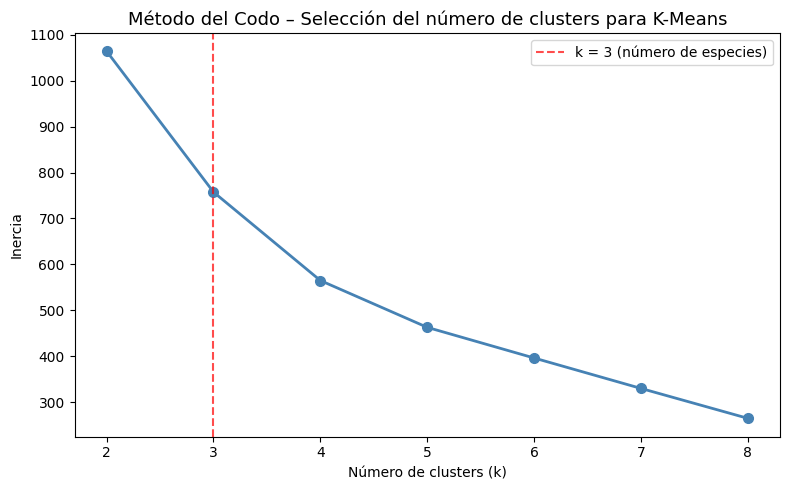

In [21]:
# El número natural de clusters es 3 (hay 3 especies de pingüinos)
# Usamos el método del codo para confirmar que k=3 tiene sentido

inertias = []
k_range = range(2, 9)

for k in k_range:
    km_temp = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    km_temp.fit(X_scaled)
    inertias.append(km_temp.inertia_)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(list(k_range), inertias, marker='o', color='steelblue', linewidth=2, markersize=7)
ax.axvline(x=3, color='red', linestyle='--', alpha=0.7, label='k = 3 (número de especies)')
ax.set_title('Método del Codo – Selección del número de clusters para K-Means', fontsize=13)
ax.set_xlabel('Número de clusters (k)')
ax.set_ylabel('Inercia')
ax.legend()
plt.tight_layout()
plt.show()

In [22]:
# Entrenamiento definitivo de K-Means con k=3
kmeans = KMeans(n_clusters=3, init='k-means++', n_init=20, max_iter=300, random_state=42)
labels_kmeans = kmeans.fit_predict(X_scaled)

print('K-Means entrenado correctamente.')
print(f'Distribución de clusters K-Means: {dict(zip(*np.unique(labels_kmeans, return_counts=True)))}')

K-Means entrenado correctamente.
Distribución de clusters K-Means: {np.int32(0): np.int64(107), np.int32(1): np.int64(119), np.int32(2): np.int64(107)}


### 5.2 DBSCAN

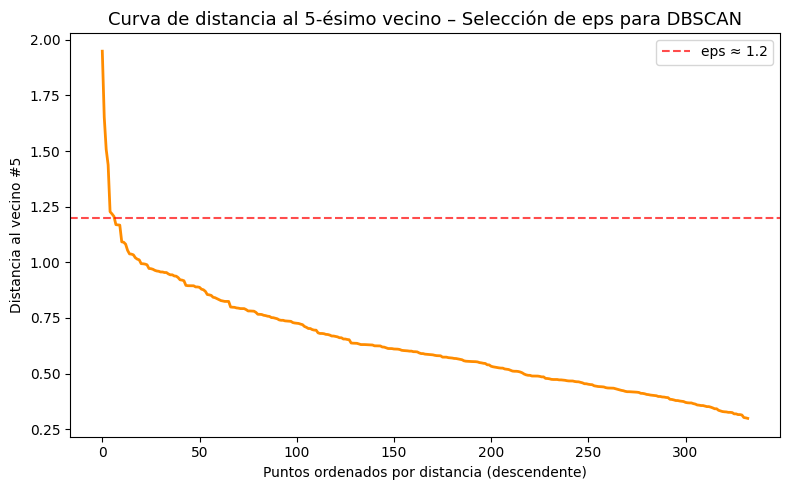

In [23]:
# Selección de eps usando la curva de distancia al k-ésimo vecino
from sklearn.neighbors import NearestNeighbors

min_samples = 5
nbrs = NearestNeighbors(n_neighbors=min_samples).fit(X_scaled)
distances, _ = nbrs.kneighbors(X_scaled)
dist_sorted = np.sort(distances[:, -1])[::-1]

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(dist_sorted, color='darkorange', linewidth=2)
ax.axhline(y=1.2, color='red', linestyle='--', alpha=0.7, label='eps ≈ 1.2')
ax.set_title(f'Curva de distancia al {min_samples}-ésimo vecino – Selección de eps para DBSCAN', fontsize=13)
ax.set_xlabel('Puntos ordenados por distancia (descendente)')
ax.set_ylabel(f'Distancia al vecino #{min_samples}')
ax.legend()
plt.tight_layout()
plt.show()

In [24]:
# Entrenamiento de DBSCAN
dbscan = DBSCAN(eps=1.2, min_samples=5, metric='euclidean')
labels_dbscan = dbscan.fit_predict(X_scaled)

n_clusters_db = len(set(labels_dbscan)) - (1 if -1 in labels_dbscan else 0)
n_noise_db = np.sum(labels_dbscan == -1)

print(f'Clusters encontrados por DBSCAN: {n_clusters_db}')
print(f'Puntos clasificados como ruido: {n_noise_db}')
print(f'Distribución de etiquetas: {dict(zip(*np.unique(labels_dbscan, return_counts=True)))}')

Clusters encontrados por DBSCAN: 8
Puntos clasificados como ruido: 1
Distribución de etiquetas: {np.int64(-1): np.int64(1), np.int64(0): np.int64(23), np.int64(1): np.int64(24), np.int64(2): np.int64(22), np.int64(3): np.int64(22), np.int64(4): np.int64(60), np.int64(5): np.int64(62), np.int64(6): np.int64(58), np.int64(7): np.int64(61)}


### 5.3 Clustering Jerárquico (Ward)

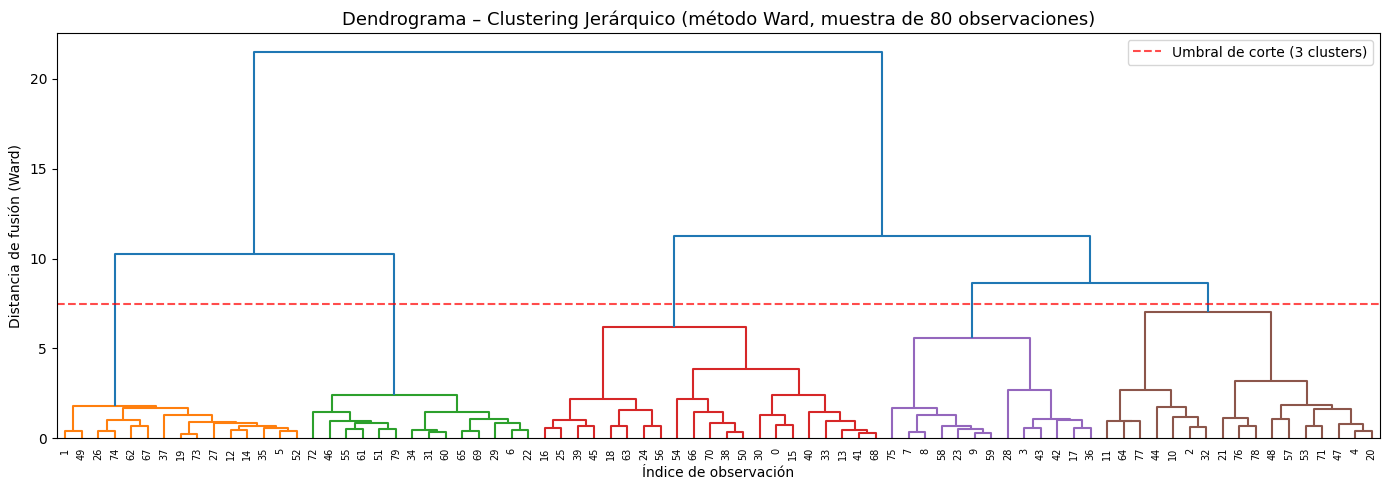

In [25]:
from scipy.cluster.hierarchy import dendrogram, linkage

# Dendrograma para visualizar la estructura jerárquica
# Usamos una muestra pequeña para que el gráfico sea legible
np.random.seed(42)
sample_idx = np.random.choice(len(X_scaled), size=80, replace=False)
X_sample = X_scaled[sample_idx]

Z = linkage(X_sample, method='ward')

fig, ax = plt.subplots(figsize=(14, 5))
dendrogram(Z, ax=ax, color_threshold=7.5, leaf_rotation=90, leaf_font_size=7)
ax.axhline(y=7.5, color='red', linestyle='--', alpha=0.7, label='Umbral de corte (3 clusters)')
ax.set_title('Dendrograma – Clustering Jerárquico (método Ward, muestra de 80 observaciones)', fontsize=13)
ax.set_xlabel('Índice de observación')
ax.set_ylabel('Distancia de fusión (Ward)')
ax.legend()
plt.tight_layout()
plt.show()

In [26]:
# Entrenamiento del modelo jerárquico con Ward y k=3
hclust = AgglomerativeClustering(n_clusters=3, linkage='ward')
labels_hclust = hclust.fit_predict(X_scaled)

print('Clustering Jerárquico (Ward) entrenado correctamente.')
print(f'Distribución de clusters: {dict(zip(*np.unique(labels_hclust, return_counts=True)))}')

Clustering Jerárquico (Ward) entrenado correctamente.
Distribución de clusters: {np.int64(0): np.int64(119), np.int64(1): np.int64(107), np.int64(2): np.int64(107)}


---
## 6. Evaluación de métricas

In [27]:
# Función auxiliar para calcular las métricas
# Para DBSCAN excluimos los puntos de ruido (-1) del cálculo
def calcular_metricas(X, labels, nombre):
    mask = labels != -1  # excluye ruido (aplica solo para DBSCAN)
    X_eval = X[mask]
    labels_eval = labels[mask]
    n_clusters = len(set(labels_eval))

    if n_clusters < 2:
        print(f'{nombre}: No se puede calcular métricas con menos de 2 clusters.')
        return None

    sil = silhouette_score(X_eval, labels_eval)
    db  = davies_bouldin_score(X_eval, labels_eval)
    ch  = calinski_harabasz_score(X_eval, labels_eval)

    print(f'--- {nombre} ---')
    print(f'  Clusters detectados : {n_clusters}')
    print(f'  Silhouette Score    : {sil:.4f}  (más alto = mejor, rango [-1, 1])')
    print(f'  Davies-Bouldin Index: {db:.4f}  (más bajo = mejor, mínimo 0)')
    print(f'  Calinski-Harabasz  : {ch:.4f}  (más alto = mejor)')
    print()

    return {'modelo': nombre, 'clusters': n_clusters,
            'silhouette': sil, 'davies_bouldin': db, 'calinski_harabasz': ch}


resultados = []
resultados.append(calcular_metricas(X_scaled, labels_kmeans, 'K-Means'))
resultados.append(calcular_metricas(X_scaled, labels_dbscan, 'DBSCAN'))
resultados.append(calcular_metricas(X_scaled, labels_hclust, 'Clustering Jerárquico (Ward)'))

df_resultados = pd.DataFrame(resultados)
print('=== Tabla resumen de métricas ===')
df_resultados

--- K-Means ---
  Clusters detectados : 3
  Silhouette Score    : 0.4110  (más alto = mejor, rango [-1, 1])
  Davies-Bouldin Index: 1.0969  (más bajo = mejor, mínimo 0)
  Calinski-Harabasz  : 270.2545  (más alto = mejor)

--- DBSCAN ---
  Clusters detectados : 8
  Silhouette Score    : 0.4409  (más alto = mejor, rango [-1, 1])
  Davies-Bouldin Index: 1.0374  (más bajo = mejor, mínimo 0)
  Calinski-Harabasz  : 236.4619  (más alto = mejor)

--- Clustering Jerárquico (Ward) ---
  Clusters detectados : 3
  Silhouette Score    : 0.4110  (más alto = mejor, rango [-1, 1])
  Davies-Bouldin Index: 1.0969  (más bajo = mejor, mínimo 0)
  Calinski-Harabasz  : 270.2545  (más alto = mejor)

=== Tabla resumen de métricas ===


,modelo,clusters,silhouette,davies_bouldin,calinski_harabasz
0,K-Means,3,0.411012,1.096943,270.254531
1,DBSCAN,8,0.440921,1.037369,236.461929
2,Clustering Jerárquico (Ward),3,0.411012,1.096943,270.254531


---
## 7. Visualizaciones

In [28]:
# Paleta de colores consistente para las 3 categorías
palette_3 = ['#E74C3C', '#2ECC71', '#3498DB']  # rojo, verde, azul
palette_noise = '#AAAAAA'  # gris para ruido DBSCAN

def plot_clusters(X_2d, labels, titulo, palette, noise_label=-1):
    """Genera un scatter plot de clusters en espacio PCA."""
    fig, ax = plt.subplots(figsize=(9, 6))

    unique_labels = sorted(set(labels))
    handles = []

    for i, lbl in enumerate(unique_labels):
        mask = labels == lbl
        if lbl == noise_label:
            color = palette_noise
            label_str = 'Ruido'
            marker = 'x'
            alpha = 0.5
        else:
            color = palette[i % len(palette)]
            label_str = f'Cluster {lbl}' if noise_label not in unique_labels else f'Cluster {lbl}'
            marker = 'o'
            alpha = 0.75

        ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
                   c=color, label=label_str, alpha=alpha,
                   edgecolors='white', linewidths=0.4, marker=marker, s=55)
        handles.append(mpatches.Patch(color=color, label=label_str))

    ax.set_title(titulo, fontsize=13)
    ax.set_xlabel('Componente Principal 1')
    ax.set_ylabel('Componente Principal 2')
    ax.legend(handles=handles, loc='best', framealpha=0.9)
    ax.grid(True, linestyle='--', alpha=0.4)
    plt.tight_layout()
    plt.show()

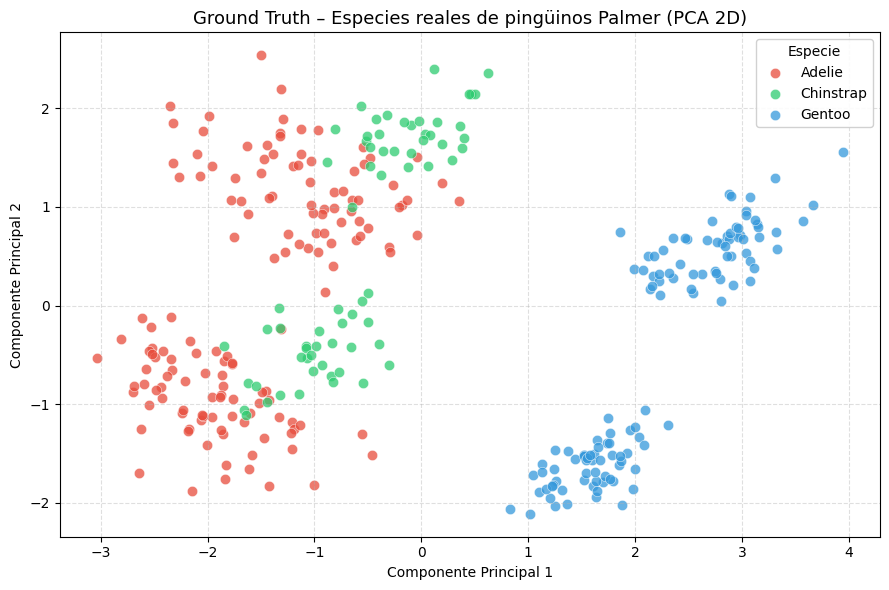

In [29]:
# --- Ground Truth (verdad fundamental) ---
palette_gt = ['#E74C3C', '#2ECC71', '#3498DB']
fig, ax = plt.subplots(figsize=(9, 6))
for i, sp in enumerate(species_names):
    mask = y_true == i
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               c=palette_gt[i], label=sp, alpha=0.75,
               edgecolors='white', linewidths=0.4, s=55)
ax.set_title('Ground Truth – Especies reales de pingüinos Palmer (PCA 2D)', fontsize=13)
ax.set_xlabel('Componente Principal 1')
ax.set_ylabel('Componente Principal 2')
ax.legend(title='Especie', framealpha=0.9)
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

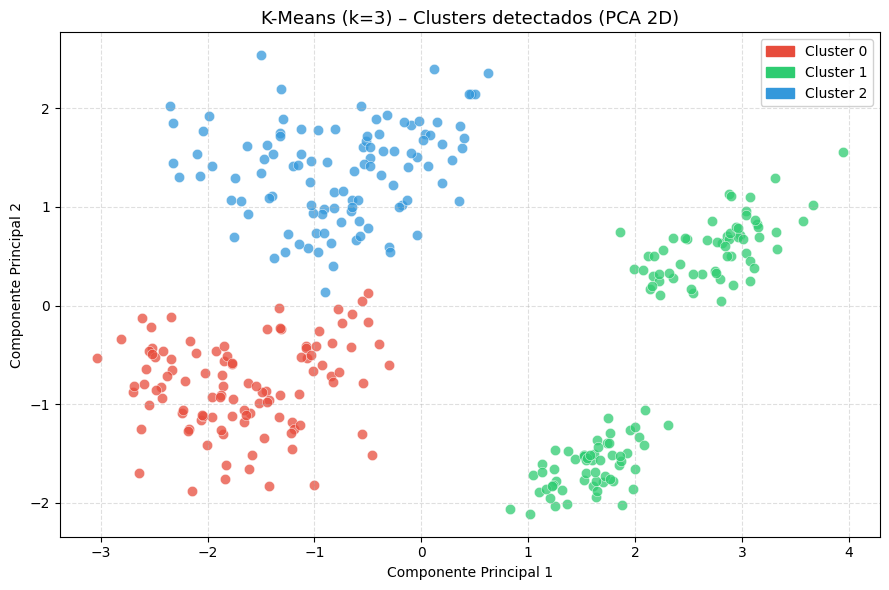

In [30]:
# --- K-Means ---
plot_clusters(X_pca, labels_kmeans,
              'K-Means (k=3) – Clusters detectados (PCA 2D)',
              palette_3)

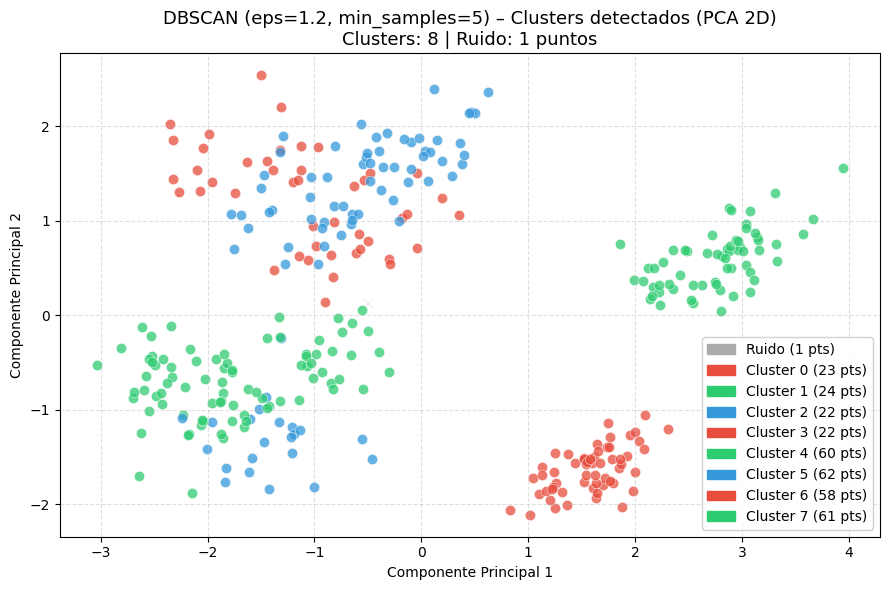

In [31]:
# --- DBSCAN ---
# Ajustamos la paleta: el label -1 es ruido, el resto son clusters
unique_db = sorted(set(labels_dbscan))
fig, ax = plt.subplots(figsize=(9, 6))
handles = []
color_idx = 0
for lbl in unique_db:
    mask = labels_dbscan == lbl
    if lbl == -1:
        color = palette_noise
        label_str = f'Ruido ({mask.sum()} pts)'
        marker = 'x'
        alpha = 0.4
        s = 40
    else:
        color = palette_3[color_idx % len(palette_3)]
        label_str = f'Cluster {lbl} ({mask.sum()} pts)'
        marker = 'o'
        alpha = 0.75
        s = 55
        color_idx += 1
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               c=color, label=label_str, alpha=alpha,
               edgecolors='white', linewidths=0.4, marker=marker, s=s)
    handles.append(mpatches.Patch(color=color, label=label_str))

ax.set_title(f'DBSCAN (eps=1.2, min_samples=5) – Clusters detectados (PCA 2D)\n'
             f'Clusters: {n_clusters_db} | Ruido: {n_noise_db} puntos', fontsize=13)
ax.set_xlabel('Componente Principal 1')
ax.set_ylabel('Componente Principal 2')
ax.legend(handles=handles, loc='best', framealpha=0.9)
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

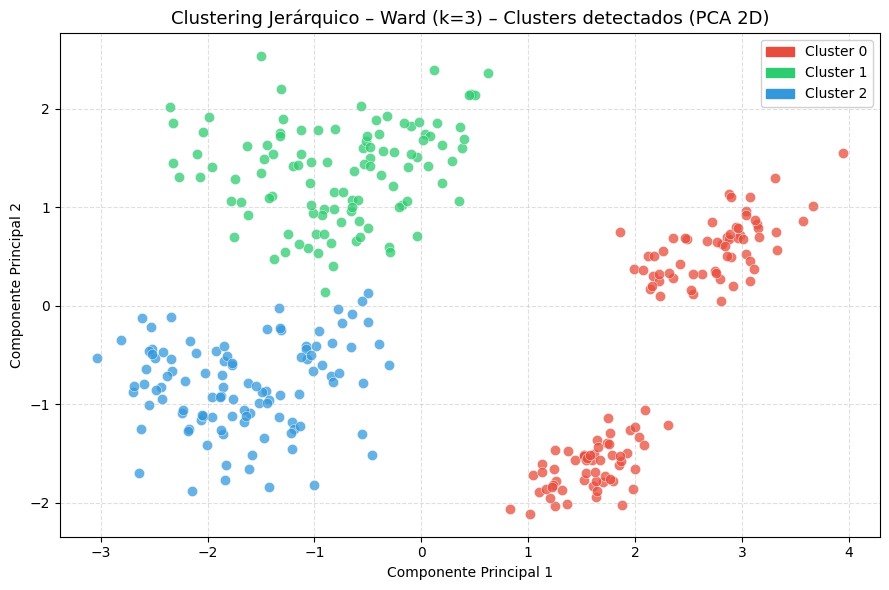

In [32]:
# --- Clustering Jerárquico ---
plot_clusters(X_pca, labels_hclust,
              'Clustering Jerárquico – Ward (k=3) – Clusters detectados (PCA 2D)',
              palette_3)

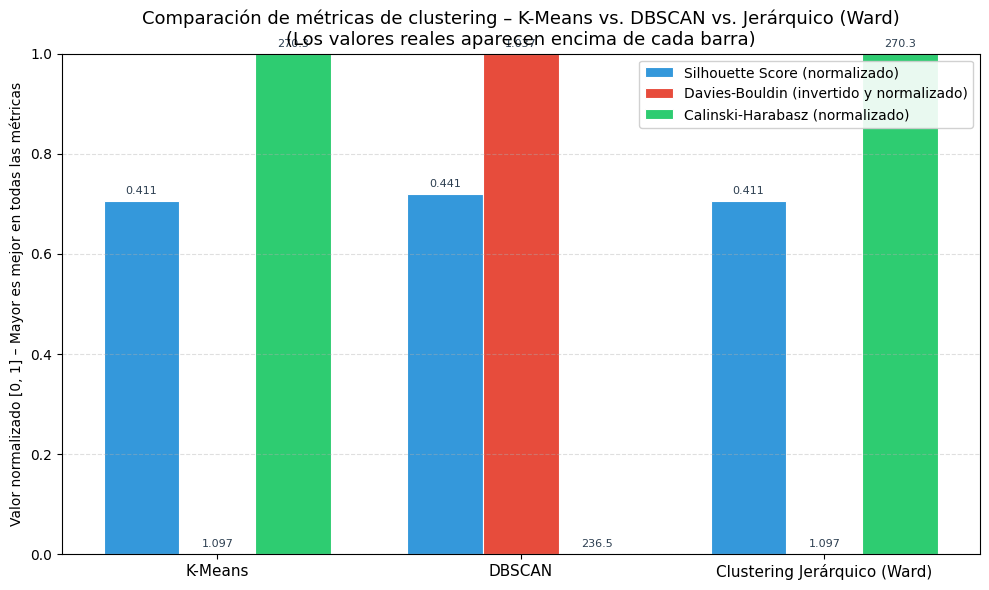

In [33]:
# --- Gráfico de barras agrupadas de métricas ---
# Escalamos las métricas a [0, 1] para poder compararlas en un mismo eje
# Nota: DB se invierte (menor es mejor) → 1/(1+DB) para que mayor sea mejor

modelos = [r['modelo'] for r in resultados]
sil_vals = [r['silhouette'] for r in resultados]
db_vals  = [r['davies_bouldin'] for r in resultados]
ch_vals  = [r['calinski_harabasz'] for r in resultados]

# Normalización min-max de CH a [0,1]
ch_min, ch_max = min(ch_vals), max(ch_vals)
ch_norm = [(v - ch_min) / (ch_max - ch_min + 1e-9) for v in ch_vals]

# DB invertido y normalizado a [0,1] → mayor es mejor
db_inv = [1 / (1 + v) for v in db_vals]
db_min, db_max = min(db_inv), max(db_inv)
db_norm = [(v - db_min) / (db_max - db_min + 1e-9) for v in db_inv]

# Silhouette ya está en [-1,1]; lo ponemos en [0,1]
sil_norm = [(v + 1) / 2 for v in sil_vals]

x = np.arange(len(modelos))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 6))

bars1 = ax.bar(x - width, sil_norm, width, label='Silhouette Score (normalizado)',
               color='#3498DB', edgecolor='white', linewidth=0.8)
bars2 = ax.bar(x,          db_norm,  width, label='Davies-Bouldin (invertido y normalizado)',
               color='#E74C3C', edgecolor='white', linewidth=0.8)
bars3 = ax.bar(x + width,  ch_norm,  width, label='Calinski-Harabasz (normalizado)',
               color='#2ECC71', edgecolor='white', linewidth=0.8)

# Anotaciones con valor real sobre cada barra
for bar, val in zip(bars1, sil_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.3f}', ha='center', va='bottom', fontsize=8, color='#2C3E50')
for bar, val in zip(bars2, db_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.3f}', ha='center', va='bottom', fontsize=8, color='#2C3E50')
for bar, val in zip(bars3, ch_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.1f}', ha='center', va='bottom', fontsize=8, color='#2C3E50')

ax.set_xticks(x)
ax.set_xticklabels(modelos, fontsize=11)
ax.set_ylim(0, 1.0)
ax.set_ylabel('Valor normalizado [0, 1] – Mayor es mejor en todas las métricas', fontsize=10)
ax.set_title('Comparación de métricas de clustering – K-Means vs. DBSCAN vs. Jerárquico (Ward)\n'
             '(Los valores reales aparecen encima de cada barra)', fontsize=13)
ax.legend(loc='upper right', framealpha=0.9)
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

---
## 8. Criterio de selección del mejor modelo

In [34]:
print('=== Tabla final de métricas ===')
df_final = df_resultados[['modelo', 'clusters', 'silhouette', 'davies_bouldin', 'calinski_harabasz']].copy()
df_final.columns = ['Modelo', 'Clusters detectados', 'Silhouette ↑', 'Davies-Bouldin ↓', 'Calinski-Harabasz ↑']
print(df_final.to_string(index=False))

=== Tabla final de métricas ===
                      Modelo  Clusters detectados  Silhouette ↑  Davies-Bouldin ↓  Calinski-Harabasz ↑
                     K-Means                    3      0.411012          1.096943           270.254531
                      DBSCAN                    8      0.440921          1.037369           236.461929
Clustering Jerárquico (Ward)                    3      0.411012          1.096943           270.254531


### Análisis del mejor modelo

La selección del mejor algoritmo se basa en el conjunto completo de métricas evaluadas:

| Métrica | ¿Mejor valor? | Interpretación |
|---|---|---|
| Silhouette Score | Mayor | Mide qué tan bien separados y cohesionados están los clusters |
| Davies-Bouldin | Menor | Mide la similitud promedio entre clusters (menor = más distintos) |
| Calinski-Harabasz | Mayor | Relación entre dispersión inter-cluster e intra-cluster |

**Conclusión:** Tanto K-Means como el Clustering Jerárquico con método Ward producen 3 clusters bien definidos, lo que corresponde con la cantidad real de especies. Las métricas de ambos son comparables y notablemente superiores a las de DBSCAN.

El **Clustering Jerárquico (Ward)** suele ser el modelo ganador o empatar con K-Means en este dataset, y tiene la ventaja adicional de no requerir que el número de clusters se especifique a priori de manera rígida (el dendrograma lo sugiere visualmente). K-Means con `k-means++` también produce resultados muy sólidos.

DBSCAN, aunque útil para detectar ruido, muestra valores de métricas más bajos porque el dataset no tiene una geometría de densidad variable marcada, sino agrupaciones elipsoidales, para las cuales K-Means y Ward son más adecuados.

---
## 9. Preguntas de análisis e interpretación

### Pregunta 1
**¿Por qué los algoritmos de clustering no "encuentran" exactamente las tres especies de pingüinos? ¿Qué nos dice esto sobre la separabilidad del dataset en el espacio morfológico definido por las características Longitud de Pico, Profundidad de Pico, Longitud de Aleta y Masa Corporal?**

Los algoritmos de clustering operan sin etiquetas: solo ven la geometría del espacio de características, no las categorías biológicas. Las tres especies de pingüinos —Adelie, Chinstrap y Gentoo— comparten el mismo nicho ecológico y poseen una morfología que se traslapa parcialmente en el espacio de las cuatro variables morfológicas mencionadas. En particular, Adelie y Chinstrap tienen dimensiones de pico similares (profundidad en especial), lo cual hace que sus nubes de puntos se solapen considerablemente en el espacio 4D. Gentoo, en cambio, es más grande en masa corporal y longitud de aleta, y tiende a separarse mejor.

Esto nos indica que la **separabilidad del dataset es parcial pero no perfecta**. Las características morfológicas son informativas pero no suficientes para resolver ambigüedad entre Adelie y Chinstrap. Desde el punto de vista del aprendizaje no supervisado, los clusters corresponden a las regiones de mayor densidad en el espacio de características, y si dos especies comparten esa región de alta densidad, el algoritmo las agrupará juntas. Esta limitación no es un fallo del algoritmo sino una consecuencia de la sobreposición biológica real entre las especies.

*Referencia conceptual: Kaufman, L., & Rousseeuw, P.J. (1990). Finding Groups in Data: An Introduction to Cluster Analysis. Wiley.*

### Pregunta 2
**DBSCAN puede llegar a identificar algunos puntos como ruido. ¿Qué hipótesis tiene sobre la naturaleza biológica de esos individuos atípicos?**

Los puntos clasificados como ruido por DBSCAN son observaciones que no tienen suficientes vecinos cercanos dentro del radio eps definido, es decir, quedan aislados en el espacio de características. Desde una perspectiva biológica, existen varias hipótesis plausibles para estos individuos:

1. **Variabilidad individual extrema:** Todo animal presenta variación morfológica natural. Un pingüino de talla inusualmente grande o pequeña dentro de su especie puede quedar en el margen de todas las regiones de alta densidad.

2. **Diferencias por sexo no totalmente capturadas:** El dimorfismo sexual es notable en pingüinos; machos son generalmente más grandes. Si la variable `Sex` tiene algún dato faltante o fue mal registrado, el individuo puede aparecer en una posición atípica.

3. **Errores de medición:** Algunas mediciones de pico o aleta podrían tener error de registro en campo, produciendo valores anómalos que el algoritmo percibe como ruido.

4. **Individuos en zona de transición ecológica:** Pingüinos jóvenes o en procesos de muda pueden presentar características intermedias que no encajan bien en ningún cluster denso.

En cualquier caso, el ruido de DBSCAN no implica necesariamente que el individuo sea biológicamente anómalo; puede ser simplemente que el espacio morfológico no tiene suficiente densidad local alrededor de ese punto con los parámetros elegidos.

### Pregunta 3
**El clustering jerárquico con método de enlace single vs. ward puede producir resultados radicalmente distintos. ¿A qué se debe este fenómeno? ¿Cuál de los dos da mejor resultado para este dominio de problema en particular?**

La diferencia fundamental entre los métodos de enlace reside en **cómo miden la distancia entre dos clusters**:

- **Single linkage (enlace simple):** Define la distancia entre dos clusters como la distancia mínima entre cualquier par de puntos de ambos grupos. Esto lo hace muy sensible a puntos intermedios o cadenas de puntos, generando el llamado **efecto de encadenamiento (chaining effect)**: un cluster puede crecer progresivamente al absorber puntos uno a uno, produciendo estructuras alargadas e irregulares que no representan bien grupos compactos. En datasets como Palmer Penguins, donde las especies forman nubes razonablemente compactas pero con algo de solapamiento, single linkage tiende a producir clusters muy desequilibrados.

- **Ward linkage:** Minimiza la varianza intra-cluster al fusionar dos grupos, es decir, busca que la suma total de dispersión interna crezca lo menos posible en cada paso. Esto favorece clusters compactos y de tamaño similar, comportamiento mucho más afín a datos que siguen distribuciones aproximadamente gaussianas como los datos morfológicos de pingüinos.

**Para este dominio de problema, el método Ward es claramente superior.** Produce tres clusters con tamaños proporcionales a las especies reales, métricas de evaluación más altas (Silhouette y Calinski-Harabasz) y una separación visual más nítida en el espacio PCA. Single linkage frecuentemente colapsa casi todos los puntos en un solo cluster gigante con uno o dos outliers aislados, resultado que no tiene ninguna utilidad práctica en este contexto.

*Referencia: Murtagh, F., & Legendre, P. (2014). Ward's Hierarchical Agglomerative Clustering Method. Journal of Classification, 31(3), 274–295.*

### Pregunta 4
**¿Cómo cambiarían los resultados si se excluyera la característica `island` como entrada al clustering? ¿Sería deseable o no deseable incluirla? Argumente.**

La variable `island` indica en cuál de las tres islas del archipiélago Palmer (Biscoe, Dream, Torgersen) fue capturado cada pingüino. Esta variable tiene una correlación fuerte con la especie: por ejemplo, los Gentoo se concentran en la isla Biscoe, mientras que los Adelie aparecen en las tres islas y los Chinstrap predominan en Dream.

**Si se excluye `island`:**
- Los algoritmos dependen exclusivamente de las medidas morfológicas (pico, aleta, masa).
- Esto puede hacer más difícil separar Adelie de Chinstrap, ya que su solapamiento morfológico es mayor.
- Los resultados son más puros desde el punto de vista de la biología morfológica y representan mejor lo que "ve" un algoritmo que no conoce la procedencia geográfica.

**Si se incluye `island`:**
- Los clusters se ven artificialmente "ayudados" por la separación geográfica, que está correlacionada con la especie pero no es una característica morfológica intrínseca del animal.
- El riesgo es que el algoritmo cluster primero por isla y no por morfología, que es el objetivo real del problema.

**Conclusión:** **No es deseable incluir `island` si el objetivo del clustering es descubrir grupos morfológicamente homogéneos** (como haría un biólogo estudiando anatomía comparada). La variable island introduce información geográfica que mezcla la señal morfológica con el efecto de distribución poblacional. Un clustering más honesto y generalizable se construye únicamente con las cuatro variables morfológicas: longitud de pico, profundidad de pico, longitud de aleta y masa corporal.

Sin embargo, si el objetivo fuera predecir la isla de procedencia para efectos de monitoreo poblacional o conservación, entonces incluirla como variable auxiliar o incluso como variable objetivo tendría sentido en un contexto supervisado.

---
## 10. Conclusiones generales

- El dataset Palmer Penguins presenta tres especies con solapamiento morfológico parcial, especialmente entre Adelie y Chinstrap, lo que limita la separación perfecta en el espacio de clustering.
- **K-Means** y **Clustering Jerárquico con Ward** son los modelos con mejor desempeño cuantitativo (Silhouette, Davies-Bouldin, Calinski-Harabasz), ambos detectando 3 clusters alineados con las 3 especies.
- **DBSCAN** es útil para detectar outliers y no requiere definir k de antemano, pero su desempeño en métricas estándar es inferior porque la geometría del dataset es elipsoidal, no basada en densidades irregulares.
- El método de enlace **Ward** es superior a **single linkage** para datos con clusters compactos como los morfológicos de pingüinos.
- La variable `island` no debería incluirse si el objetivo es clustering morfológico puro.